In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

Loading the Dataset

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten 28x28 -> 784
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Encoder

In [ ]:
def build_autoencoder(latent_dim):

    # Encoder
    input_img = Input(shape=(784,))
    x = Dense(128, activation='relu')(input_img)
    x = Dense(64, activation='relu')(x)
    bottleneck = Dense(latent_dim, activation='relu')(x)

    # Decoder
    x = Dense(64, activation='relu')(bottleneck)
    x = Dense(128, activation='relu')(x)
    output = Dense(784, activation='sigmoid')(x)

    autoencoder = Model(input_img, output)

    autoencoder.compile(
        optimizer=Adam(),
        loss='binary_crossentropy'
    )

    return autoencoder

In [ ]:
autoencoder_2 = build_autoencoder(2)
history_2 = autoencoder_2.fit(
    x_train, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

autoencoder_32 = build_autoencoder(32)
history_32 = autoencoder_32.fit(
    x_train, x_train,
    epochs=30,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2837 - val_loss: 0.2327
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2238 - val_loss: 0.2162
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.2123 - val_loss: 0.2074
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2046 - val_loss: 0.2023
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1997 - val_loss: 0.1975
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1956 - val_loss: 0.1939
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1926 - val_loss: 0.1915
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1906 - val_loss: 0.1901
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1891 - val_loss: 0.1883
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1878 - val_loss: 0.1880
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1868 - val_loss: 0.1866
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 

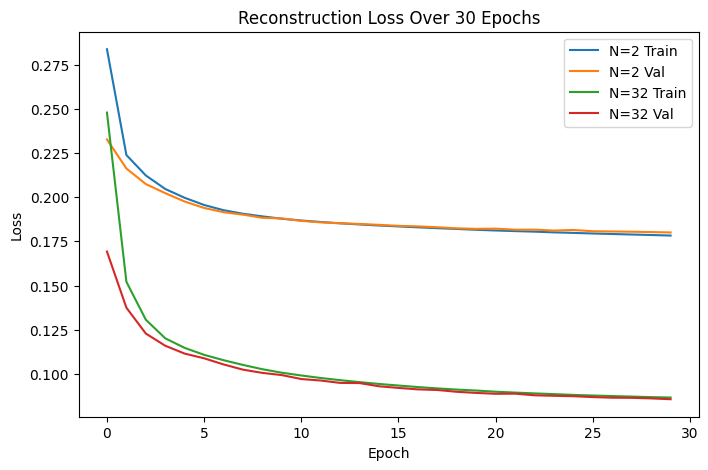

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_2.history['loss'], label="N=2 Train")
plt.plot(history_2.history['val_loss'], label="N=2 Val")

plt.plot(history_32.history['loss'], label="N=32 Train")
plt.plot(history_32.history['val_loss'], label="N=32 Val")

plt.title("Reconstruction Loss Over 30 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Results

In [ ]:
decoded_2 = autoencoder_2.predict(x_test)
decoded_32 = autoencoder_32.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


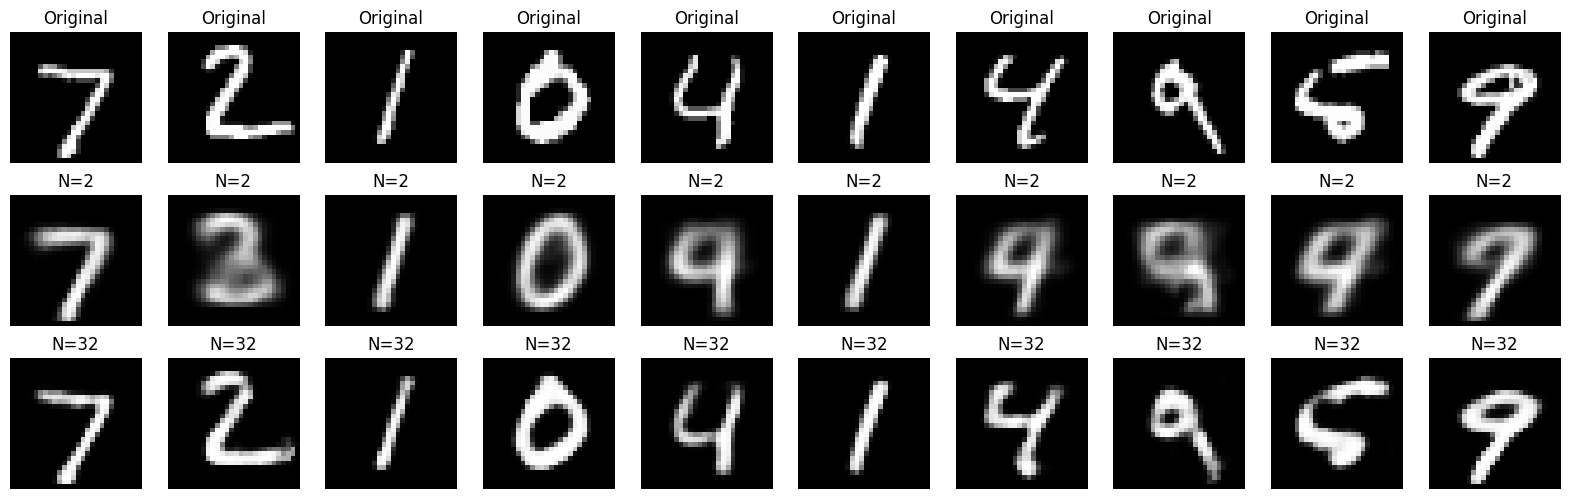

In [ ]:
n = 10
plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Reconstructed (N=2)
    ax = plt.subplot(3, n, i+n+1)
    plt.imshow(decoded_2[i].reshape(28,28), cmap='gray')
    plt.title("N=2")
    plt.axis("off")

    # Reconstructed (N=32)
    ax = plt.subplot(3, n, i+2*n+1)
    plt.imshow(decoded_32[i].reshape(28,28), cmap='gray')
    plt.title("N=32")
    plt.axis("off")

plt.show()

In [ ]:
autoencoder_2.save("autoencoder_n2.keras")